# CPA on Firmware Implementation of Kuznyechik (GOST)

## GOST Trace Capture

In [65]:
SCOPETYPE = 'CWNANO' # options: OPENADC, CWNANO  
PLATFORM = 'CWNANO' # options: CWLITEXMEGA/CW308_XMEGA, CWLITEARM/CW308_STM32F3, CWNANO 
CRYPTO_TARGET='KUZNYECHIK'
SS_VER='SS_VER_1_1'

In [66]:
%run "../Setup_Scripts/Setup_Generic.ipynb"

INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.
INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.
INFO: Found ChipWhisperer😍


In [67]:
scope.adc.samples = 50000 #options: 96000 for CW-PRO (CW1200), 24400 for CW-Lite, 131070 for CW-Husky

In [68]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd ../../firmware/mcu/simpleserial-gost
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3

Building for platform CWNANO with CRYPTO_TARGET=KUZNYECHIK
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:12.2.rel1-1) 12.2.1 20221205
Copyright (C) 2022 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Size after:
   text	   data	    bss	    dec	    hex	filename
   5928	     16	   1624	   7568	   1d90	simpleserial-gost-CWNANO.elf
+--------------------------------------------------------
+ Built for platform CWNANO Built-in Target (STM32F030) with:
+ CRYPTO_TARGET = KUZNYECHIK
+ CRYPTO_OPTIONS = AES128C
+--------------------------------------------------------


In [69]:
cw.program_target(scope, prog, "../../firmware/mcu/simpleserial-gost/simpleserial-gost-{}.hex".format(PLATFORM))

Detected known STMF32: STM32F03xx4/03xx6
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5943 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5943 bytes


In [70]:
from tqdm.notebook import trange
import numpy as np
import time
from os import urandom

trace_array = []
textin_array = []

text = urandom(16)

N = 350

for i in trange(N, desc='Capturing traces'):
    scope.arm()
    
    target.simpleserial_write('p', text)
    
    ret = scope.capture()
    if ret:
        print("Target timed out!")
        continue
    
    response = target.simpleserial_read('r', 16)
    
    trace_array.append(scope.get_last_trace())
    textin_array.append(text)
    
    text = urandom(16)
    
trace_array = np.array(trace_array)



#сохранить данные, потом удалить
#textin_array = np.array(textin_array)
#np.savez("captured_data.npz", trace_array=trace_array, textin_array=textin_array)



Capturing traces:   0%|          | 0/350 [00:00<?, ?it/s]

In [71]:
scope.dis()
target.dis()

In [72]:
assert len(trace_array) == N
print("✔️ OK to continue!")

✔️ OK to continue!


Again, let's quickly plot a trace to make sure everything looks as expected:

In [73]:
%matplotlib notebook
import matplotlib.pylab as plt

plt.figure()
plt.plot(trace_array[0], 'r')
plt.plot(trace_array[N//2], 'g')
plt.plot(trace_array[N-1], 'b')
plt.show()

<IPython.core.display.Javascript object>

## Kuznyechik Model and Hamming Weight

In [74]:
sbox = [
    252, 238, 221, 17, 207, 110, 49, 22, 251, 196, 250, 218, 35, 197, 4, 77, 233,
    119, 240, 219, 147, 46, 153, 186, 23, 54, 241, 187, 20, 205, 95, 193, 249, 24, 101,
    90, 226, 92, 239, 33, 129, 28, 60, 66, 139, 1, 142, 79, 5, 132, 2, 174, 227, 106, 143,
    160, 6, 11, 237, 152, 127, 212, 211, 31, 235, 52, 44, 81, 234, 200, 72, 171, 242, 42,
    104, 162, 253, 58, 206, 204, 181, 112, 14, 86, 8, 12, 118, 18, 191, 114, 19, 71, 156,
    183, 93, 135, 21, 161, 150, 41, 16, 123, 154, 199, 243, 145, 120, 111, 157, 158, 178,
    177, 50, 117, 25, 61, 255, 53, 138, 126, 109, 84, 198, 128, 195, 189, 13, 87, 223,
    245, 36, 169, 62, 168, 67, 201, 215, 121, 214, 246, 124, 34, 185, 3, 224, 15, 236,
    222, 122, 148, 176, 188, 220, 232, 40, 80, 78, 51, 10, 74, 167, 151, 96, 115, 30, 0,
    98, 68, 26, 184, 56, 130, 100, 159, 38, 65, 173, 69, 70, 146, 39, 94, 85, 47, 140, 163,
    165, 125, 105, 213, 149, 59, 7, 88, 179, 64, 134, 172, 29, 247, 48, 55, 107, 228, 136,
    217, 231, 137, 225, 27, 131, 73, 76, 63, 248, 254, 141, 83, 170, 144, 202, 216, 133,
    97, 32, 113, 103, 164, 45, 43, 9, 91, 203, 155, 37, 208, 190, 229, 108, 82, 89, 166,
    116, 210, 230, 244, 180, 192, 209, 102, 175, 194, 57, 75, 99, 182
]

lookup = sbox

kuz_lvec = [0x94, 0x20, 0x85, 0x10, 0xC2, 0xC0, 0x01, 0xFB,
            0x01, 0xC0, 0xC2, 0x10, 0x85, 0x20, 0x94, 0x01]

def kuz_mul_gf256(x, y):
    z = 0
    for i in range(8):
        if (y & 1):
            z ^= x
        if (x & 0x80):
            x = ((x << 1) & 0xFF) ^ 0xC3
        else:
            x = (x << 1) & 0xFF
        y >>= 1
    return z

def L(inputdata):
    res = [block for block in inputdata]
    x = 0
    for j in range(16):
        # An LFSR with 16 elements from GF(2^8)
        x = res[15] # since lvec[15] = 1

        for i in range(14,-1,-1):
            res[i+1] = res[i]
            x ^= kuz_mul_gf256(res[i], kuz_lvec[i])
        res[0] = x
    return res

def SX(inputdata, key):
    return sbox[inputdata ^ key]

HW = [bin(n).count("1") for n in range(0, 256)]

## Differential Attack Implementaiton

### Пропустить, если устройство подключено!!!

In [1]:
# TODO: Implement the differential attack on the Kuznyechik cipher
# (use "SOLN_Lab 3_3 - DPA on Firmware Implementation of AES" from ../sca101 as a reference)
import numpy as np
data = np.load("captured_data.npz")
trace_array = data["trace_array"]
textin_array = data["textin_array"]

sbox = [
    252, 238, 221, 17, 207, 110, 49, 22, 251, 196, 250, 218, 35, 197, 4, 77, 233,
    119, 240, 219, 147, 46, 153, 186, 23, 54, 241, 187, 20, 205, 95, 193, 249, 24, 101,
    90, 226, 92, 239, 33, 129, 28, 60, 66, 139, 1, 142, 79, 5, 132, 2, 174, 227, 106, 143,
    160, 6, 11, 237, 152, 127, 212, 211, 31, 235, 52, 44, 81, 234, 200, 72, 171, 242, 42,
    104, 162, 253, 58, 206, 204, 181, 112, 14, 86, 8, 12, 118, 18, 191, 114, 19, 71, 156,
    183, 93, 135, 21, 161, 150, 41, 16, 123, 154, 199, 243, 145, 120, 111, 157, 158, 178,
    177, 50, 117, 25, 61, 255, 53, 138, 126, 109, 84, 198, 128, 195, 189, 13, 87, 223,
    245, 36, 169, 62, 168, 67, 201, 215, 121, 214, 246, 124, 34, 185, 3, 224, 15, 236,
    222, 122, 148, 176, 188, 220, 232, 40, 80, 78, 51, 10, 74, 167, 151, 96, 115, 30, 0,
    98, 68, 26, 184, 56, 130, 100, 159, 38, 65, 173, 69, 70, 146, 39, 94, 85, 47, 140, 163,
    165, 125, 105, 213, 149, 59, 7, 88, 179, 64, 134, 172, 29, 247, 48, 55, 107, 228, 136,
    217, 231, 137, 225, 27, 131, 73, 76, 63, 248, 254, 141, 83, 170, 144, 202, 216, 133,
    97, 32, 113, 103, 164, 45, 43, 9, 91, 203, 155, 37, 208, 190, 229, 108, 82, 89, 166,
    116, 210, 230, 244, 180, 192, 209, 102, 175, 194, 57, 75, 99, 182
]

lookup = sbox #для переделки кода

### Итоговый код

In [2]:
# Calculate difference of means on given input/traces for bit bitnum; also return grouping for each guess
def dom(input_data, traces, bitnum, num_byte_textin):    
    groups = [0] * 256
    diff_vect = [0] * 256
    traces = np.array(traces) # Convert to numpy so we can slice better below

    # Group each trace based on each guess
    for guess in range(0, 256):
        # Vector: for each trace, apply lookup table
        transformed = np.array([lookup[guess ^ p[num_byte_textin]] for p in input_data])
        # Vector: for each trace, 0 or 1
        group = transformed >> bitnum & 1
        # Save grouping
        groups[guess] = group
        
        # Calculate means for group zero and one
        mean_zero = np.mean(traces[group==0],axis=0)
        mean_one  = np.mean(traces[group==1],axis=0)
        
        # Calc difference
        diff_vect[guess] = mean_one - mean_zero
        
    return (diff_vect, groups)

In [3]:
# Return best guess for key given input data and traces, and specific bit number
def best_guess(input_data, traces, bitnum, num_byte_textin):
    # Calculate DoM for given bit and input
    (diff_vect,groups) = dom(input_data, traces, bitnum, num_byte_textin)
    
    # Vector: For each of the 256 guesses the strongest peak in the DoM trace
    guess_max = np.max(np.abs(diff_vect),axis=1)
    
    # Return guess for which the peak is the highest of all guesses
    return np.argmax(guess_max)

In [7]:
# Create AES traces and re-guess key
bitnum = 7
for num_byte_textin in range(16):
    best_key = best_guess(textin_array,trace_array,bitnum, num_byte_textin)
    print("Best guess from byte %d: 0x%02x"%(num_byte_textin, best_key))

Best guess from byte 0: 0x6c
Best guess from byte 1: 0xec
Best guess from byte 2: 0xc6
Best guess from byte 3: 0x7f
Best guess from byte 4: 0x28
Best guess from byte 5: 0x7d
Best guess from byte 6: 0x08
Best guess from byte 7: 0x3d
Best guess from byte 8: 0xeb
Best guess from byte 9: 0x87
Best guess from byte 10: 0x66
Best guess from byte 11: 0xf0
Best guess from byte 12: 0x73
Best guess from byte 13: 0x8b
Best guess from byte 14: 0x36
Best guess from byte 15: 0x6e


###### Ключ

[0x6c,0xec,0xc6,0x7f,0x28,0x7d,0x08,0x3d,
0xeb,0x87,0x66,0xf0,0x73,0x8b,0x36,0xcf,
0x16,0x4e,0xd9,0xb2,0x46,0x95,0x10,0x90,
0x86,0x9d,0x08,0x28,0x5d,0x2e,0x19,0x3b]

### Графики атаки

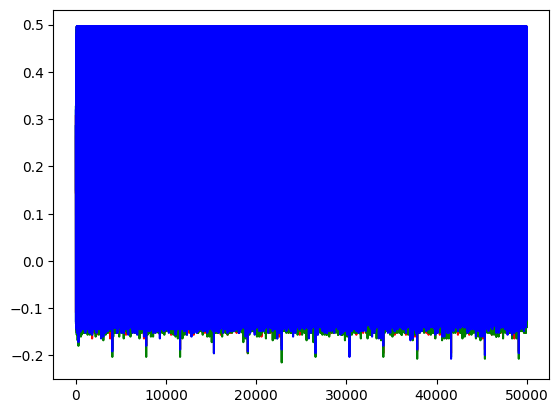

In [54]:


%matplotlib notebook
%matplotlib inline
import matplotlib.pylab as plt

plt.figure()
plt.plot(trace_array[0], 'r')
plt.plot(trace_array[N//2], 'g')
plt.plot(trace_array[N-1], 'b')
plt.show()



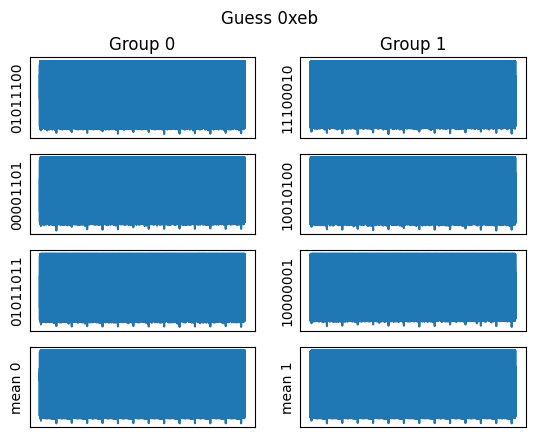

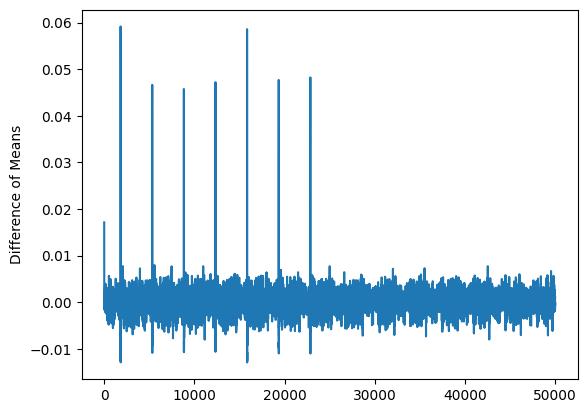

In [64]:
import numpy as np
import random
import pylab as py


def trcplot(trace, title="", xlabel="", ylabel="", label="", axs=None):
    if not axs:
        fig, axs = py.subplots()
    axs.set_title(title)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.plot(trace, label=label)
# Make a nice DoM plot for a particular guess
def plot_dom_guess(input_data, traces, diff_vect, groups, guess, ylim=None):
    lines = 3
    fig, axs = py.subplots(lines+1,2)
    fig.suptitle("Guess " + hex(guess))
    means = [None, None]

    # For each group {0,1}
    for group in range(2):
        # Obtain traces and data for group
        group_traces = traces[groups[guess]==group]
        group_data = input_data[groups[guess]==group]
        
        # Plot traces
        for trace in range(lines):
            # Get data and perform lookup; format it
            data = lookup[guess ^ group_data[trace][num_byte_textin]] 
            datastr = bin(data)[2:].zfill(8) 
            
            # Plot it
            curaxs = axs[trace,group]
            trcplot(group_traces[trace], ylabel=datastr, axs=curaxs)
            curaxs.set_xticks([])
            curaxs.set_yticks([])

        # Plot mean for group
        axs[0,group].set_title("Group " + str(group))
        curaxs = axs[lines,group]
        curaxs.set_xticks([])
        curaxs.set_yticks([])
        means[group] = np.mean(group_traces,axis=0)
        trcplot(means[group], ylabel="mean " + str(group), axs=curaxs)
    py.savefig("fig/10_8x_{}_top.svg".format(hex(guess)), format="svg")
        
    # Plot difference of means
    trcplot(diff_vect[guess], ylabel="Difference of Means") 
    if ylim:
        py.ylim(ylim)
    py.savefig("fig/10_8x_{}_bottom.svg".format(hex(guess)), format="svg")
    
# Correct guess
num_byte_textin = 8
(diff_vect,groups) = dom(textin_array, trace_array, 7, num_byte_textin)
plot_dom_guess(textin_array, trace_array, diff_vect, groups, 0xeb)
ylim = py.ylim() # Get y scale

### Проверка ключа (ниже ничего не писать)

In [1]:
# bestguess[32]
key = [0x6c,0xec,0xc6,0x7f,0x28,0x7d,0x08,0x3d,
       0xeb,0x87,0x66,0xf0,0x73,0x8b,0x36,0xcf,
       0x16,0x4e,0xd9,0xb2,0x46,0x95,0x10,0x90,
       0x86,0x9d,0x08,0x28,0x5d,0x2e,0x19,0x3b]

for bnum in range(32):
    assert bestguess[bnum] == key[bnum], \
    "Byte {} failed, expected {:02X} got {:02X}".format(bnum, key[bnum], bestguess[bnum])
print("✔️ OK to continue!")

NameError: name 'bestguess' is not defined